#  Обратное распространение ошибки

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann
* http://cs231n.stanford.edu/handouts/linear-backprop.pdf
* https://www.adityaagrawal.net/blog/deep_learning/bprop_fc
* https://en.wikipedia.org/wiki/Stochastic_gradient_descent

In [44]:
!pip install torchtyping

In [45]:
from torchtyping import TensorType, patch_typeguard
from typeguard import typechecked
import torch as th

Scalar = TensorType[()]
patch_typeguard()

## Задачи для совместного разбора

1\. Реализуйте обратное распространение ошибки для модели нейрона с квадратичной функцией потерь при условии, что на вход нейрону поступает вектор `inputs`. Проверьте корректность вычисления градиентов, воспользовавшись возможностями по автоматическому дифференцированию `torch`.

2\. Настройте модель нейрона, используя метод стохастического градиентного спуска и собственную реализацию обратного распространения ошибки.

In [46]:
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt

X, y, coef = make_regression(n_features=4, n_informative=4, coef=True, bias=0.5, random_state=42)
X = th.FloatTensor(X)
y = th.FloatTensor(y)

In [47]:
y_preds = neuron.forward(X)
(y_preds - y).pow(2).mean()

tensor(9560.1768)

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Реализуйте обратное распространение ошибки для модели нейрона с функцией потерь MSE при условии, что на вход нейрону поступает пакет (двумерный тензор) `inputs`. Проверьте корректность вычисления градиентов, воспользовавшись возможностями по автоматическому дифференцированию `torch`.

$$\mathbf{X} = \begin{bmatrix}
x_{10} & x_{11} & \ldots & x_{1m} \\
x_{20} & x_{21} & \ldots & x_{2m} \\
\vdots & \vdots & \ddots & \vdots \\
x_{k0} & x_{k1} & \ldots & x_{km} \\
\end{bmatrix}
\mathbf{Y} = \begin{bmatrix}
y_{1} \\
y_{2} \\
\vdots \\
y_{k} \\
\end{bmatrix}
\mathbf{W} = \begin{bmatrix}
w_{0} \\
w_{1} \\
\vdots \\
w_{m} \\
\end{bmatrix}$$

$$\hat{\mathbf{Y}} = \mathbf{X}\times \mathbf{W}$$

$$L = \frac{1}{k}\sum_{k}{(\hat{y_k}-y_k)^2}$$

$$\nabla_{\hat{\mathbf{Y}}} L=\begin{bmatrix}
\frac{\partial L}{\partial \hat{y_1}} \\
\frac{\partial L}{\partial \hat{y_2}} \\
\vdots \\
\frac{\partial L}{\partial \hat{y_k}} \\
\end{bmatrix} = \frac{2}{k}\begin{bmatrix}
\hat{y_1} - y_1 \\
\hat{y_2} - y_2 \\
\vdots \\
\hat{y_k} - y_k \\
\end{bmatrix}$$

$$\boldsymbol{\nabla_{\mathbf{W}} L = \mathbf{X}^T\nabla_{\hat{\mathbf{Y}}} L}$$

- [ ] Проверено на семинаре

In [48]:
import torch as th

class NeuronBatch:
    def __init__(self, n_features: int, seed: int | None = None, grad: bool = False):
        if seed is not None:
            th.manual_seed(seed)
        # Добавьте дополнительный вес для сдвига (bias)
        # задайте requires_grad у этого тензора, чтобы иметь возможность протестировать
        # автоматическое дифференцирование от torch
        self.weights: TensorType["n_features_with_bias", 1] = th.randn(n_features + 1, 1, requires_grad=grad) #Вектор-столбец весов из нормального распределения

    def add_ones_col(self, inputs: TensorType["batch", "n_features"]) -> TensorType["batch", "n_features_with_bias"]:
        """Добавляет столбец из единиц в начало матрицы inputs"""
        ones = th.ones((inputs.shape[0], 1), dtype=inputs.dtype, device=inputs.device) #Инициализация единичного вектор-столбца
        return th.cat([ones, inputs], dim=1) #Возвращает конкатенацию единичного вектор-столбца и вводных данных

    def forward(self, inputs: TensorType["batch", "n_features"]) -> TensorType["batch", 1]:
        Xb = self.add_ones_col(inputs) #Добавляем единичныц вектор-столбец
        return Xb @ self.weights #Матричное умножение признаков на веса, получаем выходные данные

    def backward(self, inputs: TensorType["batch", "n_features"], dnext: TensorType["batch", 1]) -> None:
        Xb = self.add_ones_col(inputs)
        self.dinputs = dnext @ self.weights[1:, :].T                          #\ Аккумулируем градиент функции потерь
        self.dweights: TensorType["n_features_with_bias", 1] = Xb.T @ dnext   #/ повторяя .backward() из пакета PyTorch

In [49]:
class MSELoss:
    def forward(self, y_pred: TensorType["batch", 1], y_true: TensorType["batch", 1]) -> Scalar:
        return ((y_pred - y_true)**2).mean()

    def backward(self, y_pred: TensorType["batch", 1], y_true: TensorType["batch", 1]) -> None:
        self.dinput: TensorType["batch", 1] = 2 * (y_pred - y_true) / y_pred.numel()

In [50]:
X, y, coef = make_regression(n_samples=100, n_features=4, n_informative=4, coef=True, bias=0.5, random_state=42)
X = th.FloatTensor(X)
y_true = th.FloatTensor(y).reshape(-1, 1)

neuron = NeuronBatch(n_features=4, seed=42, grad=True)
y_pred = neuron.forward(X)
mse = MSELoss()
loss = mse.forward(y_pred, y_true)
mse.backward(y_pred, y_true)
neuron.backward(X, mse.dinput)

print('dweights через функцию NeuronBatch =', neuron.dweights.flatten()[:5])

loss.backward()
print('Проверка через Autograd weights.grad =', neuron.weights.grad.flatten()[:5])
print('Совпадение градиентов:', th.allclose(neuron.dweights, neuron.weights.grad, atol=1e-6))

dweights через функцию NeuronBatch = tensor([  -9.1164,   -4.9875, -170.1456,  -69.3295,  -60.0142],
       grad_fn=<SliceBackward0>)
Проверка через Autograd weights.grad = tensor([  -9.1164,   -4.9875, -170.1456,  -69.3295,  -60.0142])
Совпадение градиентов: True


<p class="task" id="2"></p>

2\. Настройте модель нейрона, используя метод мини-пакетного градиентного спуска.

Используйте обратное распространение ошибки, реализованное самостоятельно. Выведите на экран полученные и правильные коэффициенты модели.

- [ ] Проверено на семинаре

In [51]:
from sklearn.datasets import make_regression
from torch.utils.data import DataLoader, TensorDataset
import torch as th

X, y, coef = make_regression(n_features=4, n_informative=4, coef=True, bias=0.5, random_state=42)
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)

In [52]:
neuron = NeuronBatch(n_features=4, seed=42)
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

lr = 0.0012
epoches = 500

for ep in range(epoches):
  for X, y in loader:
    y_pred = neuron.forward(X)
    loss = mse.forward(y, y_pred)
    mse.backward(y, y_pred)
    neuron.backward(X, mse.dinput)
    neuron.weights.data -= lr * neuron.dweights

print(f'Полученные коэффициенты нейрона: {neuron.weights.flatten()}')

w_true = th.tensor([0.5] + list(coef), dtype=th.float32)
print(f'Правильные веса: {w_true}')

Полученные коэффициенты нейрона: tensor([ -2539.0439,   1685.0911, -11096.7529,  -7092.7451,   -595.7476])
Правильные веса: tensor([ 0.5000,  5.6375, 86.4722, 27.3407, 41.4819])


<p class="task" id="3"></p>

3\. Реализуйте обратное распространение ошибки для модели полносвязного слоя с функцией потерь MSE при условии, что на вход нейрону поступает пакет (двумерный тензор) `inputs`.  Проверьте корректность вычисления градиентов, воспользовавшись возможностями по автоматическому дифференцированию `torch`.

Обратите внимание, что вам потребуются оба градиента $ \boldsymbol{\nabla_{\mathbf{W}} L }$ и $\boldsymbol{\nabla_{\mathbf{X}} L}$ для распространения ошибки с несколькими слоями.

$$\mathbf{X} = \begin{bmatrix}
x_{10} & x_{11} & \ldots & x_{1m} \\
x_{20} & x_{21} & \ldots & x_{2m} \\
\vdots & \vdots & \ddots & \vdots \\
x_{k0} & x_{k1} & \ldots & x_{km} \\
\end{bmatrix}
\mathbf{Y} = \begin{bmatrix}
y_{1} \\
y_{2} \\
\vdots \\
y_{k} \\
\end{bmatrix}
\mathbf{W} = \begin{bmatrix}
w_{01} & w_{02} & \ldots & w_{0n} \\
w_{11} & w_{12} & \ldots & w_{1n} \\
\vdots & \vdots & \ddots & \vdots \\
w_{m1} & w_{m2} & \ldots & w_{mn} \\
\end{bmatrix}$$

$$\hat{\mathbf{Y}} = \mathbf{X}\times \mathbf{W}$$

$$\nabla_{\hat{\mathbf{Y}}} L = \begin{bmatrix}
\frac{\partial L}{\partial \hat{y_{11}}} & \ldots & \frac{\partial L}{\partial \hat{y_{1n}}} \\
\vdots & \vdots & \vdots \\
\frac{\partial L}{\partial \hat{y_{k1}}} & \ldots & \frac{\partial L}{\partial \hat{y_{kn}}} \\
\end{bmatrix}$$

$$\boldsymbol{\nabla_{\mathbf{W}} L = \mathbf{X}^T\times \nabla_{\hat{\mathbf{Y}}} L}$$
$$\boldsymbol{\nabla_{\mathbf{X}} L = \nabla_{\hat{\mathbf{Y}}} L\times \mathbf{W}^T}$$

- [ ] Проверено на семинаре

In [53]:
import torch as th

class Linear:
    def __init__(self, n_features: int, n_neurons: int, seed: int | None = None, grad: bool = False):
        if seed is not None:
            th.manual_seed(seed)
        # Добавьте дополнительный вес для сдвига
        # задайте requires_grad у этого тензора, чтобы иметь возможность протестировать
        # автоматическое дифференцирование от torch
        self.weights: TensorType["n_features_with_bias", "n_neurons"] = th.randn(n_features + 1, n_neurons, requires_grad=True, dtype=th.float32)

    def add_ones_col(self, inputs: TensorType["batch", "n_features"]) -> TensorType["batch", "n_features_with_bias"]:
        """Добавляет столбец из единиц в начало матрицы inputs"""
        ones = th.ones(inputs.shape[0], 1, dtype=th.float32)
        return th.cat([ones, inputs], dim=1)

    def forward(self, inputs: TensorType["batch", "n_features"]) -> TensorType["batch", "n_neurons"]:
        Xb = self.add_ones_col(inputs)
        return Xb @ self.weights

    def backward(self, inputs: TensorType["batch", "n_features"], dnext: TensorType["batch", "n_neurons"]):
        Xb = self.add_ones_col(inputs)
        self.dinputs = dnext @ self.weights[1:, :].T # dE/dy_pred * w - градиент по входным данным (являющийся градиентом выходных данных предыдущего слоя)
        self.dweights: TensorType["n_features_with_bias", "n_neurons"] = Xb.T @ dnext # dE/dy_pred * dy_pred/dw, где dy_pred/dw = Xb.T - градиент по весам

In [54]:
class MSELoss:
    def forward(self, y_pred: TensorType["batch", "n_neurons"], y_true: TensorType["batch", "n_neurons"]) -> Scalar:
        return th.mean(th.square(y_pred - y_true))

    def backward(self, y_pred: TensorType["batch", "n_neurons"], y_true: TensorType["batch", "n_neurons"]) -> None:
        self.dinput: TensorType["batch", "n_neurons"] = 2 * (y_pred - y_true) / y_pred.numel()

In [55]:
X, y, coef = make_regression(
    n_samples=100,
    n_features=4,
    n_informative=4,
    n_targets=2,
    coef=True,
    bias=0.5,
    random_state=42
)

X = th.FloatTensor(X)
y_true = th.FloatTensor(y)

layer1 = Linear(n_features=4, n_neurons=2, seed=42, grad=True)
y_pred = layer1.forward(X)
loss = mse.forward(y_pred, y_true)
mse.backward(y_pred, y_true)
layer1.backward(X, mse.dinput)

loss.backward()
print('\nLinear dweights совпадает с autograd: ',
      th.allclose(layer1.dweights, layer1.weights.grad, atol=1e-6))


Linear dweights совпадает с autograd:  True


<p class="task" id="4"></p>

4\. Настройте полносвязный слой, используя метод пакетного градиентного спуска. Используйте обратное распространение ошибки, реализованное самостоятельно. Выведите на экран полученные и правильные коэффициенты модели.

- [ ] Проверено на семинаре

In [89]:
loader = DataLoader(TensorDataset(X, y_true), batch_size=32, shuffle=True)

lr = 0.0013
epochs = 500

for epoch in range(epochs):
    for X, y in loader:
        y_pred = layer1.forward(X)
        loss_val = mse.forward(y_pred, y)
        mse.backward(y_pred, y)
        layer1.backward(X, mse.dinput)
        layer1.weights.data -= lr * layer1.dweights

w_true = th.tensor(coef)
print(f'Полученные веса При помощи Linear:\n {layer1.weights.data[1:]}\n')
print(f'Правильные веса w_true:\n {w_true}')

Полученные веса При помощи Linear:
 tensor([[ 75.4200, 120.7115],
        [-18.5782, -25.7123],
        [ 14.3726,  57.2183],
        [-28.8410, -28.0481]])

Правильные веса w_true:
 tensor([[81.2901, 99.9718],
        [99.6637, 55.5432],
        [41.4820, 27.3407],
        [ 5.6375, 86.4722]], dtype=torch.float64)


<p class="task" id="5"></p>

5\. Используя решения предыдущих задач, создайте нейросеть и решите задачу регрессии. При наличии корректно реализованных методов `backward` у `Linear` и `MSE` вы можете обобщить процедуру распространения ошибки на любое количество слоев. Реализуйте и обучите модель, состояющую из двух полносвязных слоев:

1. Полносвязный слой с 10 нейронами;
2. Полносвязный слой с 1 нейроном;

Схематично процедура обратного распространения ошибки представлена на рис. ниже.

В процессе обучения сохраняйте промежуточные прогнозы моделей. Визуализируйте облако точек и прогнозы модели в начале, середине и после окончания процесса обучения (не обязательно три, можно взять больше промежуточных вариантов).


- [ ] Проверено на семинаре

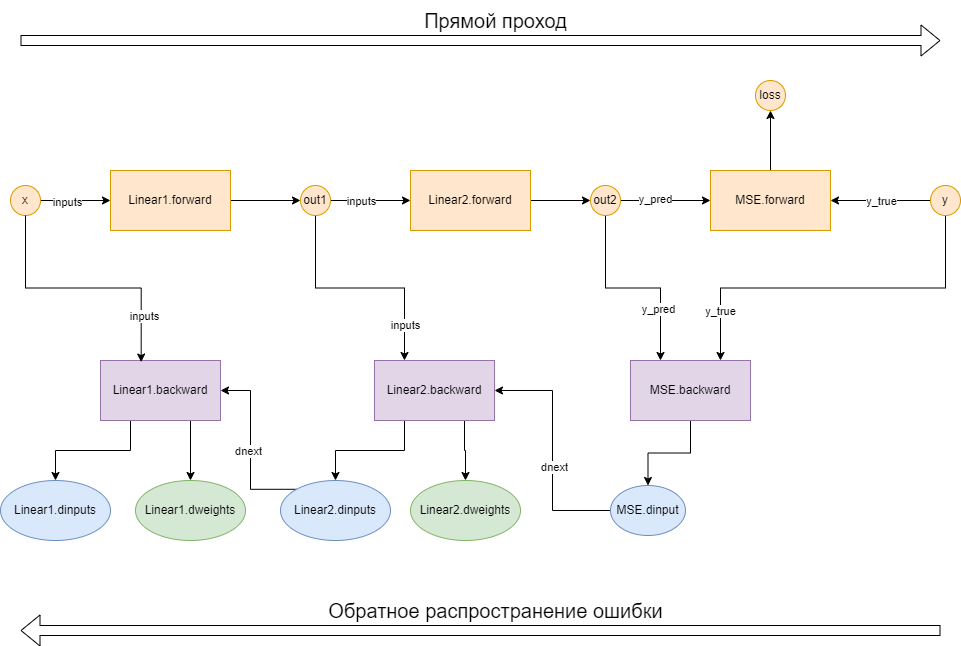

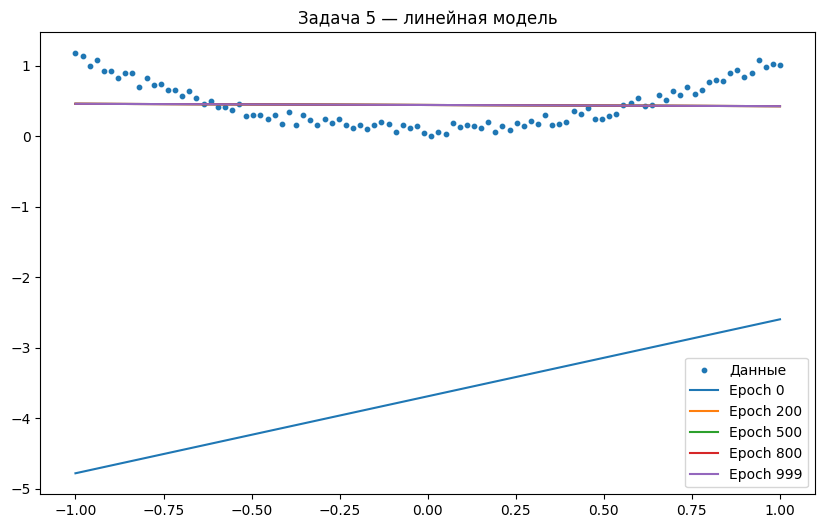

In [92]:
th.manual_seed(42)
X_reg = th.linspace(-1, 1, 100).view(-1, 1)
y_reg = X_reg.pow(2) + 0.2 * th.rand(X_reg.size())

layer1 = Linear(n_features=1, n_neurons=10, seed=42)
layer2 = Linear(n_features=10, n_neurons=1, seed=43)

preds_history = []
lr = 0.01
epochs = 1000

for epoch in range(epochs):
    out1 = layer1.forward(X_reg)
    y_pred = layer2.forward(out1)

    loss = mse.forward(y_pred, y_reg)
    mse.backward(y_pred, y_reg)

    layer2.backward(out1, mse.dinput)
    layer1.backward(X_reg, layer2.dinputs)

    layer1.weights.data -= lr * layer1.dweights
    layer2.weights.data -= lr * layer2.dweights

    if epoch in [0, 200, 500, 800, 999]:
        preds_history.append((epoch, y_pred.detach().clone()))

plt.figure(figsize=(10, 6))
plt.scatter(X_reg.numpy(), y_reg.numpy(), s=10, label='Данные')
for e, p in preds_history:
    plt.plot(X_reg.numpy(), p.numpy(), label=f'Epoch {e}')
plt.legend()
plt.title('Задача 5 — линейная модель')
plt.show()

<p class="task" id="6"></p>

6\. Модель из предыдущей задачи является линейной и не способна качественно предсказать искомую зависимость. Для того, чтобы сделать модель нелинейной, в нейронных сетях используются функции активации. Для того, чтобы встроить такую функцию в процесс обратного распространения ошибки, необходимо реализовать соответствующий слой с методами `forward` и `backward`.

$$
f(x) = \max(0, x)
$$

$$
\frac{\partial L}{\partial x} = \frac{\partial L}{\partial f}\frac{\partial f}{\partial x} = \frac{\partial L}{\partial f}
\begin{cases}
1 & \text{если } x \ge 0 \\
0 & \text{если } x <  0
\end{cases}
$$

Здесь $L$ - это функция (слой), следующая за ReLU в потоке вычислений.

Реализуйте и обучите модель, состояющую из двух полносвязных слоев, разделенных функцией активации ReLU:
1. Полносвязный слой с 10 нейронами
2. Активация ReLU
3. Полносвязный слой с 1 нейроном

В процессе обучения сохраняйте промежуточные прогнозы моделей. Визуализируйте облако точек и прогнозы модели в начале, середине и после окончания процесса обучения (не обязательно три, можно взять больше промежуточных вариантов).




- [ ] Проверено на семинаре

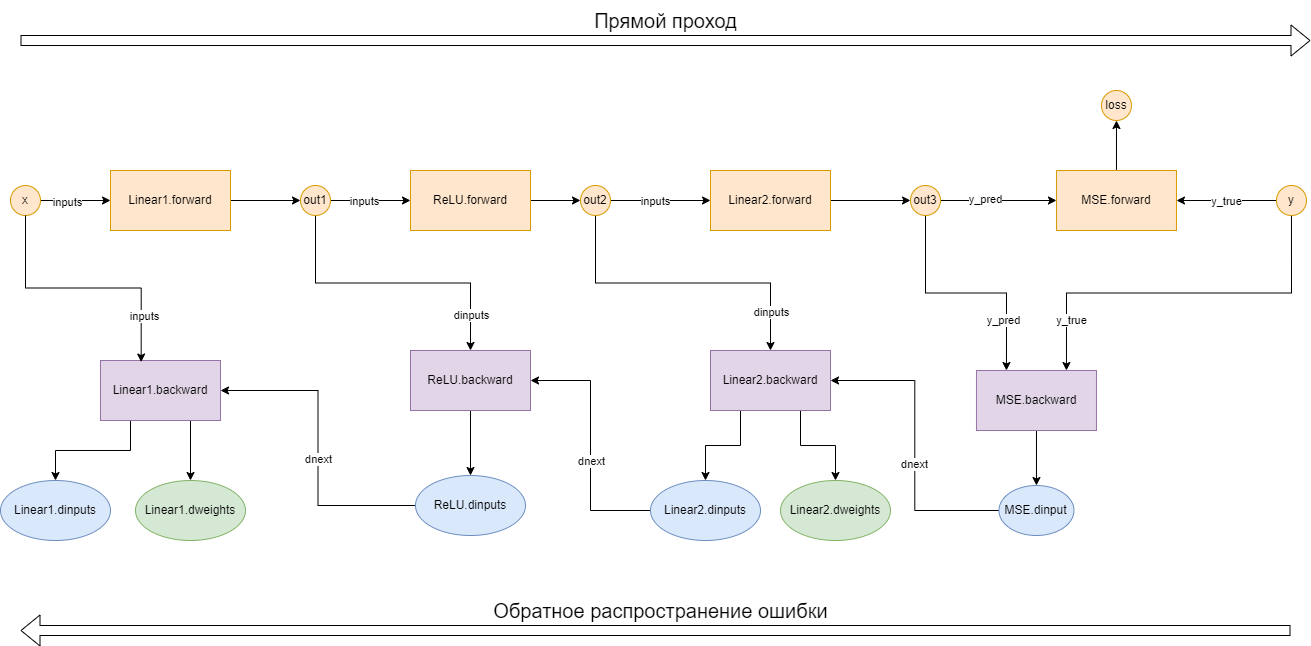

In [101]:
class ReLU:
    def forward(self, inputs: TensorType["batch", "n_features"]) -> TensorType["batch", "n_features"]:
        return th.where(
            inputs >= 0,
            inputs,
            0
        )

    def backward(
        self,
        inputs: TensorType["batch", "n_features"],
        dvalues: TensorType["batch", "n_features"]
    ) -> TensorType["batch", "n_features"]:
        dinputs = dvalues.clone()
        dinputs[inputs < 0] = 0
        return dinputs

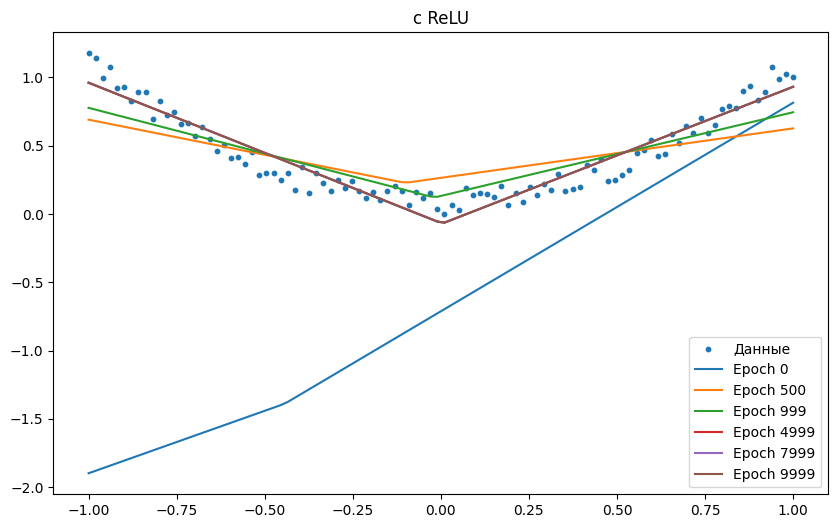

In [103]:
linear1 = Linear(n_features=1, n_neurons=10, seed=42)
relu = ReLU()
linear2 = Linear(n_features=10, n_neurons=1, seed=43)

preds_history = []
epochs = 10000

for epoch in range(epochs):
    out1 = linear1.forward(X_reg) #output первого слоя
    act = relu.forward(out1) #Функция активации для добавления нелинейности нашей сети
    y_pred = linear2.forward(act) #Вход нелинейных зависимостей функции активации

    mse.backward(y_pred, y_reg) #Расчет функции ошибки - критерия качества сети

    linear2.backward(act, mse.dinput)                   #\ Градиент dE/dw и dE/dx - реализованные в классе Linear
    dnext_relu = relu.backward(out1, linear2.dinputs)   #| + Градиент по функции активации
    linear1.backward(X_reg, dnext_relu)                 #/

    linear1.weights.data -= lr * linear1.dweights
    linear2.weights.data -= lr * linear2.dweights

    if epoch in [0, 500, 999, 4999, 7999, 9999]:
        preds_history.append((epoch, y_pred.detach().clone()))

plt.figure(figsize=(10, 6))
plt.scatter(X_reg.numpy(), y_reg.numpy(), s=10, label='Данные')
for e, p in preds_history:
    plt.plot(X_reg.numpy(), p.numpy(), label=f'Epoch {e}')
plt.legend()
plt.title('с ReLU')
plt.show()